# TN2211 Session 12:  Wave propagation in electrical circuits

## Instruments


In [2]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt
import math
import numpy as np
import time


Loading BokehJS ...

In [3]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('USB0::0xF4EC::0x1103::SDG1XDDQ802923::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808365::INSTR')

In [4]:
scope = Scope("SDS")
gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808365::INSTR
Setting memory depth to 10k points
Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDQ802923::INSTR


# Setup

In [4]:

gen.set_frequency(1, 1/2) #first output channel, then frequency in HZ

gen.set_amplitude(1, 15)

scope.write("ACQ:MDEP 10M") #set memory depth to 10M points


In [5]:
def set_freq_range(f1, f2):
    center = (f1+f2)/2
    span = f2-f1
    scope.write("FUNC1:FFT:SPAN %e" % span)
    scope.write("FUNC1:FFT:HCEN %e" % center)

In [6]:
F_max = 1e3
F_min = 0
set_freq_range(F_min, F_max)

In [7]:
def reset_fft_average():
    scope.write("FUNC1:FFT:RESET")

In [8]:
def set_fft_averages(n):
    if n == 0:
        scope.write("FUNC1:FFT:MODE NORM")
        return
    if n<4: 
        n = 4 # min allowed number
    if n>1024:
        n = 1024 # max allowed number
    else:
        scope.write("FUNC1:FFT:MODE AVER,%d" % n)

In [9]:
N = 4

set_fft_averages(N)

depth = "50M"

time_base = 1
scope.write(f"ACQ:MDEP {depth}")
scope.write("TIM:SCAL %f" % (time_base))


In [4]:
freq, spectrum, units = scope.get_fft(filename=f"average_{N}_depth_{depth}_Time_scale_{time_base*10}.csv")


NameError: name 'N' is not defined

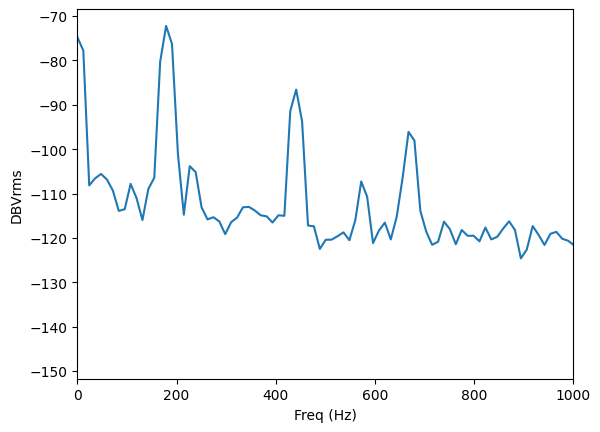

In [ ]:
plt.figure()
plt.plot(freq, spectrum)
plt.ylabel(units)
plt.xlabel("Freq (Hz)")
plt.xlim(F_min,F_max)
plt.show()

## Level 2 work

Add your own code and code cells below for your level 2 work. 

In [ ]:
depth = "50M"

time_base = 1/1000
scope.write(f"ACQ:MDEP {depth}")
scope.write("TIM:SCAL %f" % (time_base))


In [ ]:
x, t = scope.get_trace(1, filename=f"trace_depth_{depth}.csv")




Saved to file trace_depth_50M.csv


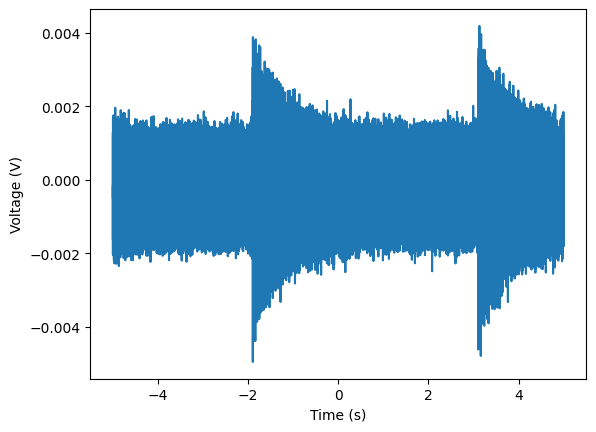

In [ ]:
plt.figure()
plt.plot(x, t)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.show()

In [18]:
depths = ["10k", "100k", "1M", "10M", "50M"]
time_bases = [1/1000, 1/100, 1/10]
F_min = 0
F_max = 1e3
set_freq_range(F_min, F_max)
set_fft_averages(4)
for time_base in time_bases: 
    for depth in depths:
        scope.write(f"ACQ:MDEP {depth}")
        gen.set_frequency(1, 1/(time_base*10))
        scope.write("TIM:SCAL %f" % (time_base))
        time.sleep(time_base*1000) # wait for the scope to acquire enough data for the FFT average
        freq, spectrum, units = scope.get_fft(filename=f"depth_{depth}_Time_scale_{time_base*10}.csv")
        x, t = scope.get_trace(1, filename=f"trace_depth_{depth}_timebase_{time_base*10}.csv")
        


Saved to file depth_10k_Time_scale_0.01.csv
Saved to file trace_depth_10k_timebase_0.01.csv
Saved to file depth_100k_Time_scale_0.01.csv
Saved to file trace_depth_100k_timebase_0.01.csv
Saved to file depth_1M_Time_scale_0.01.csv
Saved to file trace_depth_1M_timebase_0.01.csv
Saved to file depth_10M_Time_scale_0.01.csv
Saved to file trace_depth_10M_timebase_0.01.csv
Saved to file depth_50M_Time_scale_0.01.csv
Saved to file trace_depth_50M_timebase_0.01.csv
Saved to file depth_10k_Time_scale_0.1.csv
Bytes expected 2000000, Bytes received 200000


error: unpack requires a buffer of 2000000 bytes

In [41]:
depth = "10M"
time_base = 1/10

weight = 1 + 0.1027 - 0.025
L = 50



scope.write(f"ACQ:MDEP {depth}")
gen.set_frequency(1, 1/(time_base*10))
scope.write("TIM:SCAL %f" % (time_base))
time.sleep(time_base*100) # wait for the scope to acquire enough data for the FFT average
freq, spectrum, units = scope.get_fft(filename=f"depth_{depth}_Time_scale_{time_base*10}_Weight_{weight}_L_{L}.csv")
x, t = scope.get_trace(1, filename=f"trace_depth_{depth}_timebase_{time_base*10}_Weight_{weight}_L_{L}.csv")

Saved to file depth_10M_Time_scale_1.0_Weight_1.0777_L_50.csv
Saved to file trace_depth_10M_timebase_1.0_Weight_1.0777_L_50.csv


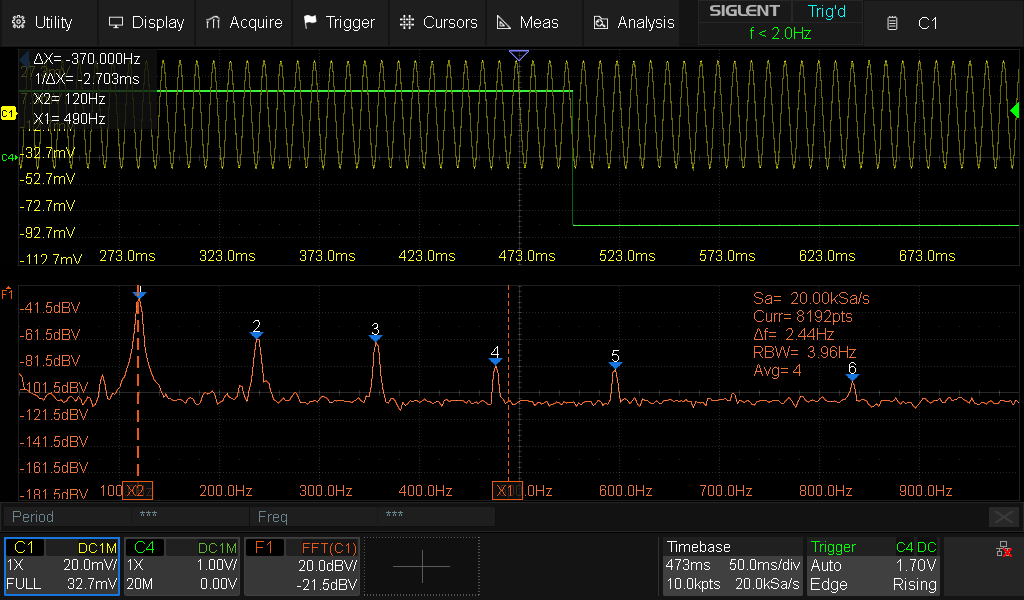

In [5]:
scope.get_screenshot()

In [12]:
scope.write("ACQ:MDEP 50M") #set memory depth to 50M points


In [13]:
freq, spectrum, units = scope.get_fft(filename=f"driven at random point with f_zero.csv")

Saved to file driven at random point with f_zero.csv


In [25]:
F_min = 0
F_max = 1e3
import scipy as sp

peaks, _ = sp.signal.find_peaks(spectrum, height=0)
Peak_freq = freq[np.array(peaks)]

plt.figure()
plt.plot(freq, spectrum)
for peak in Peak_freq:
    plt.axvline(peak, color='r', linestyle='--')
plt.ylabel(units)
plt.xlabel("Freq (Hz)")
plt.xlim(F_min,F_max)
plt.show()




TypeError: only integer scalar arrays can be converted to a scalar index

In [6]:
f = "f_1 = 238"
L_meet = "L/2"
L_drive = "L/4"
v_pp = np.arange(1, 13, 1)
scope.write("ACQ:MDEP 10M") #set memory depth to 50M points
v_pp = [13]
for v in v_pp:
    gen.set_amplitude(1, v)
    time.sleep(100)
    freq, spectrum, units = scope.get_fft(filename=f"f_1 = 238 driven at L over 4 measured 3L over 4 for {v} v_pp.csv")
    x, t = scope.get_trace(1, filename=f"f_1 = 238 driven at L over 4 measured 3L over 4_trace for {v} v_pp.csv")

Saved to file f_1 = 238 driven at L over 4 measured 3L over 4 for 13 v_pp.csv
Saved to file f_1 = 238 driven at L over 4 measured 3L over 4_trace for 13 v_pp.csv


# Experiment meet amp van x 

In [73]:
L_0 = - 0.15
L_meeting = 0.31
L = L_meeting - L_0 - 0.024

freq, spectrum, units = scope.get_fft(filename=f"f_2=357_x={L}.csv")
x, t = scope.get_trace(1, filename=f"f_2=357_x={L}.csv")

Saved to file f_2=357_x=0.43599999999999994.csv
Saved to file f_2=357_x=0.43599999999999994.csv
